# Customer Churn — EDA & Preprocessing
**Owner:** Moaz Farag
**Notebook:** 01_moaz_eda_preprocessing.ipynb


  ARTIFACT CONTRACT                                       
  Notebook: 01_moaz_eda_preprocessing.ipynb              
  INPUT:      data/raw/telco_customer_churn.csv           
  OUTPUTS:    data/cleaned/cleaned_telco.csv              
              data/summaries/                             
              assets/plots/eda/                           
  NEXT:       02_mohy_feature_engineering.ipynb           

**Objective:** This notebook performs the initial Exploratory Data Analysis (EDA) and data preprocessing on the raw Telco Customer Churn dataset. We will load the data, remove leakage columns, analyze distributions and relationships, fix data types, and encode the target variable before passing the cleaned data downstream.

## Inputs & Expected Outputs

**Inputs:**
- `data/raw/telco_customer_churn.csv`

**Outputs:**
- `data/cleaned/cleaned_telco.csv`: The primary cleaned dataset ready for feature engineering.
- `data/summaries/data_summary.csv`: A tabular summary of data types and null counts.
- `data/summaries/missing_values.csv`: A report on missing values.
- `assets/plots/eda/*.png`: Assorted EDA visualizations.

> ⚠️ LEAKAGE WARNING: Churn Score, Churn Value, Churn Reason, and CLTV will be dropped in Cell 07 before any analysis. Never use these as features.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 2. Configuration

In [2]:
# ── Paths ────────────────────────────────────────────
# ?? Project root discovery ?????????????????????????????
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    candidate_root = PROJECT_ROOT.parent
    if (candidate_root / "data").exists() and (candidate_root / "notebooks").exists():
        PROJECT_ROOT = candidate_root

if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Could not locate project root containing the data directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from runtime_audit_utils import backup_if_overwriting, record_regeneration_step

RAW_DATA_PATH     = PROJECT_ROOT / "data/raw/telco_customer_churn.csv"
CLEANED_DATA_PATH = PROJECT_ROOT / "data/cleaned/cleaned_telco.csv"
SUMMARIES_PATH    = PROJECT_ROOT / "data/summaries"
PLOTS_PATH        = PROJECT_ROOT / "assets/plots/eda"
REPORTS_PATH      = PROJECT_ROOT / "reports"

# ── Constants ─────────────────────────────────────────
RANDOM_STATE      = 42
TARGET_COLUMN     = "Churn Label"
EXPECTED_ROWS     = 7043
EXPECTED_COLS     = 33

# ── Leakage columns to drop ───────────────────────────
LEAKAGE_COLUMNS   = ["Churn Score", "Churn Value", "Churn Reason", "CLTV"]

# ── ID / geographic columns to drop later ─────────────
DROP_COLUMNS      = ["CustomerID", "Count", "Country", "State",
                     "City", "Zip Code", "Lat Long", "Latitude", "Longitude"]

for p in [CLEANED_DATA_PATH.parent, SUMMARIES_PATH, PLOTS_PATH, REPORTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("✅ Configuration complete. All directories created.")

✅ Configuration complete. All directories created.


## 3. Data Loading

In [3]:
df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
display(df.head(3))

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


### ✅ GATE 1 — Data Loading Validation
_This gate must PASS before the notebook continues._

In [4]:
if df is not None and len(df) > 0:
    print(f"✅ GATE 1.1 PASS: Dataset loaded. Shape: {df.shape}")
else:
    raise ValueError("❌ GATE 1.1 FAIL: Dataset is empty or did not load.")

if len(df) == EXPECTED_ROWS:
    print(f"✅ GATE 1.2 PASS: Row count correct — {len(df)} rows.")
else:
    print(f"⚠️ GATE 1.2 WARN: Expected {EXPECTED_ROWS} rows, got {len(df)}.")

if TARGET_COLUMN in df.columns:
    print(f"✅ GATE 1.3 PASS: Target column '{TARGET_COLUMN}' found.")
else:
    raise ValueError("❌ GATE 1.3 FAIL: Target column missing. Cannot continue.")

missing = [c for c in LEAKAGE_COLUMNS if c not in df.columns]
if not missing:
    print("✅ GATE 1.4 PASS: All leakage columns found and ready for removal.")
else:
    print(f"⚠️ GATE 1.4 WARN: Some leakage columns not found: {missing}")

print("\n🟢 GATE 1 COMPLETE — Proceeding to leakage removal.")

✅ GATE 1.1 PASS: Dataset loaded. Shape: (7043, 33)
✅ GATE 1.2 PASS: Row count correct — 7043 rows.
✅ GATE 1.3 PASS: Target column 'Churn Label' found.
✅ GATE 1.4 PASS: All leakage columns found and ready for removal.

🟢 GATE 1 COMPLETE — Proceeding to leakage removal.


## 4. Leakage Column Removal
⚠️ **Critical step.** These columns contain post-churn information.
Using them as features would make the model cheat.
They are removed NOW before any EDA, analysis, or export.

In [5]:
cols_before = list(df.columns)
df = df.drop(columns=LEAKAGE_COLUMNS, errors='ignore')
cols_after = list(df.columns)
removed = [c for c in cols_before if c not in cols_after]
print(f"Removed columns: {removed}")
print(f"Shape after removal: {df.shape}")

Removed columns: ['Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']
Shape after removal: (7043, 29)


### ✅ GATE 2 — Leakage Validation
_Confirms leakage columns are gone._

In [6]:
all_clear = True
for col in LEAKAGE_COLUMNS:
    if col in df.columns:
        print(f"❌ GATE 2 FAIL: '{col}' still in dataframe!")
        all_clear = False
    else:
        print(f"✅ '{col}' successfully removed.")

if not all_clear:
    raise ValueError("❌ GATE 2 FAIL: Leakage columns still present. STOP.")
else:
    print("\n🟢 GATE 2 PASS — All leakage columns removed. Safe to continue.")

✅ 'Churn Score' successfully removed.
✅ 'Churn Value' successfully removed.
✅ 'Churn Reason' successfully removed.
✅ 'CLTV' successfully removed.

🟢 GATE 2 PASS — All leakage columns removed. Safe to continue.


## 5. Exploratory Data Analysis (EDA)
EDA helps us understand the distributions, data types, and relationships in our dataset before we apply any preprocessing steps.

### 5.1 Dataset Overview

In [7]:
print("--- Shape ---")
print(df.shape)
print("\n--- Dtypes ---")
print(df.dtypes.value_counts())
print("\n--- Info ---")
df.info()
print("\n--- Describe ---")
display(df.describe(include='all').round(2))

--- Shape ---
(7043, 29)

--- Dtypes ---
object     23
int64       3
float64     3
Name: count, dtype: int64

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 1

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
count,7043,7043.0,7043,7043,7043,7043.00,7043,7043.00,7043.00,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.00,7043,7043
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,...,3,3,3,3,3,2,4,NaN,6531,2
top,3668-QPYBK,NaN,United States,California,Los Angeles,NaN,"33.964131, -118.272783",NaN,NaN,Male,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,1.0,NaN,NaN,NaN,93521.96,NaN,36.28,-119.80,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.76,NaN,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.79,NaN,2.46,2.16,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.09,NaN,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.00,NaN,32.56,-124.30,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.25,NaN,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.00,NaN,34.03,-121.82,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.50,NaN,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.00,NaN,36.39,-119.73,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.35,NaN,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.00,NaN,38.22,-118.04,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.85,NaN,NaN


### 5.2 Missing Values

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values found.")
else:
    display(missing_df)

missing_save = pd.DataFrame({
    'Column': df.columns,
    'Missing Count': df.isnull().sum().values,
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2).values
})
missing_save.to_csv(SUMMARIES_PATH / "missing_values.csv", index=False, encoding='utf-8')
print(f"\n📁 Saved: {SUMMARIES_PATH / 'missing_values.csv'}")

✅ No missing values found.

📁 Saved: data\summaries\missing_values.csv


### ✅ GATE 3 — Missing Value Validation
_Churn Reason missing values are EXPECTED (non-churned customers have no reason).
All other columns must be 100% complete._

In [9]:
unexpected_nulls = {
    col: df[col].isnull().sum()
    for col in df.columns
    if col != "Churn Reason" and df[col].isnull().sum() > 0
}
if unexpected_nulls:
    print(f"⚠️ GATE 3 WARN: Unexpected nulls found: {unexpected_nulls}")
    print("   → These must be resolved before export.")
else:
    print("✅ GATE 3 PASS: No unexpected missing values. All clean.")

✅ GATE 3 PASS: No unexpected missing values. All clean.

### 5.3 Duplicate Rows

In [10]:
n_dupes = df.duplicated().sum()
if n_dupes > 0:
    print(f"⚠️ Found {n_dupes} duplicate rows. Removing...")
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print(f"✅ No duplicate rows found. Shape: {df.shape}")

✅ No duplicate rows found. Shape: (7043, 29)

## 6. Visualizations

### 6.1 Churn Distribution

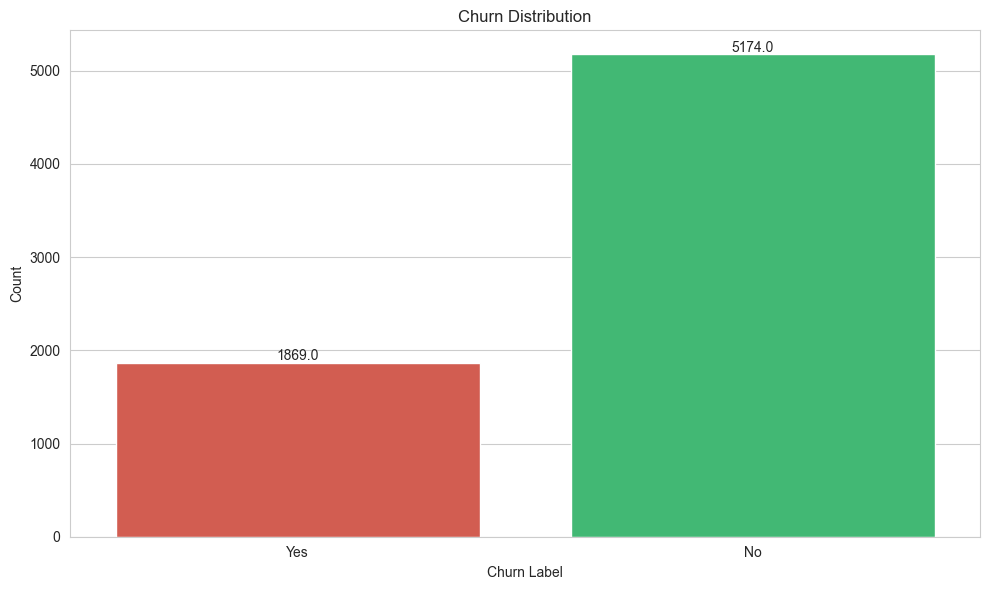

Class imbalance ratio: 73.46% No Churn / 26.54% Churn


In [11]:
plt.figure(figsize=(10,6))
ax = sns.countplot(x="Churn Label", data=df, palette=["#e74c3c", "#2ecc71"], order=["Yes", "No"])
plt.title("Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', xytext = (0, 5), textcoords = 'offset points')

plt.tight_layout()
plt.savefig(PLOTS_PATH / "01_churn_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

counts = df["Churn Label"].value_counts(normalize=True)
print(f"Class imbalance ratio: {counts['No']:.2%} No Churn / {counts['Yes']:.2%} Churn")

### 6.2 Tenure Distribution by Churn Status

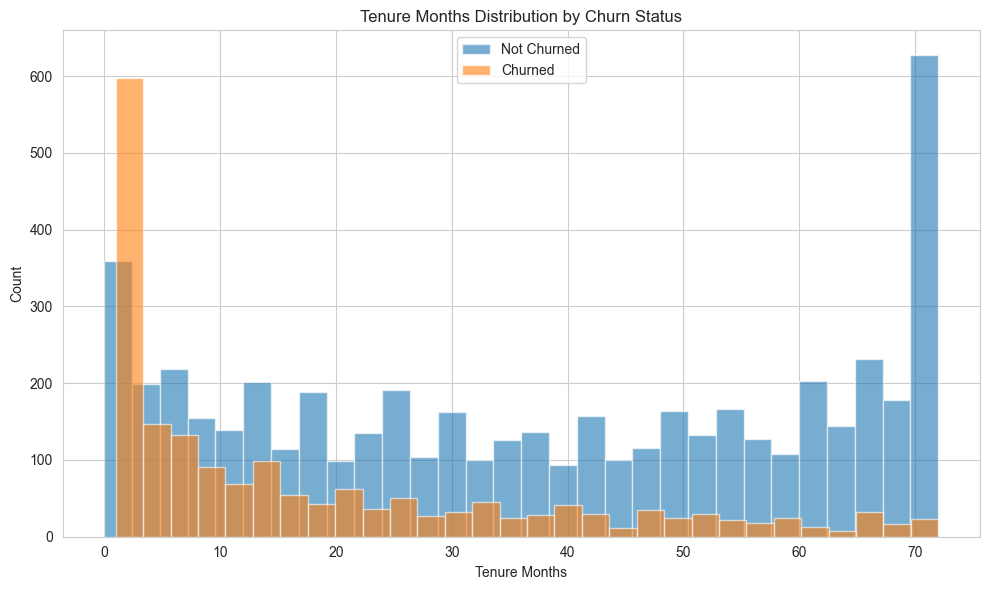

Median tenure (Not Churned): 38.0
Median tenure (Churned): 10.0


In [12]:
plt.figure(figsize=(10,6))
plt.hist(df[df["Churn Label"] == "No"]["Tenure Months"], bins=30, alpha=0.6, label="Not Churned")
plt.hist(df[df["Churn Label"] == "Yes"]["Tenure Months"], bins=30, alpha=0.6, label="Churned")
plt.title("Tenure Months Distribution by Churn Status")
plt.xlabel("Tenure Months")
plt.ylabel("Count")
plt.legend(["Not Churned", "Churned"])
plt.tight_layout()
plt.savefig(PLOTS_PATH / "02_tenure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median tenure (Not Churned): {df[df['Churn Label'] == 'No']['Tenure Months'].median()}")
print(f"Median tenure (Churned): {df[df['Churn Label'] == 'Yes']['Tenure Months'].median()}")

### 6.3 Monthly Charges by Churn Status

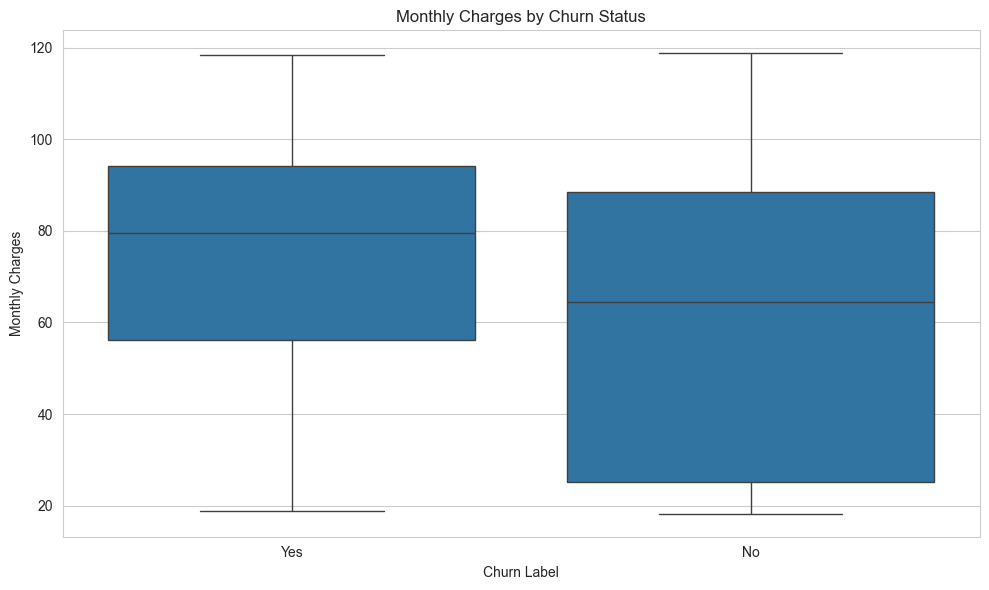

Mean monthly charge (Not Churned): 61.27
Mean monthly charge (Churned): 74.44


In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Label")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "03_monthly_charges_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Mean monthly charge (Not Churned): {df[df['Churn Label'] == 'No']['Monthly Charges'].mean():.2f}")
print(f"Mean monthly charge (Churned): {df[df['Churn Label'] == 'Yes']['Monthly Charges'].mean():.2f}")

### 6.4 Contract Type vs Churn Rate

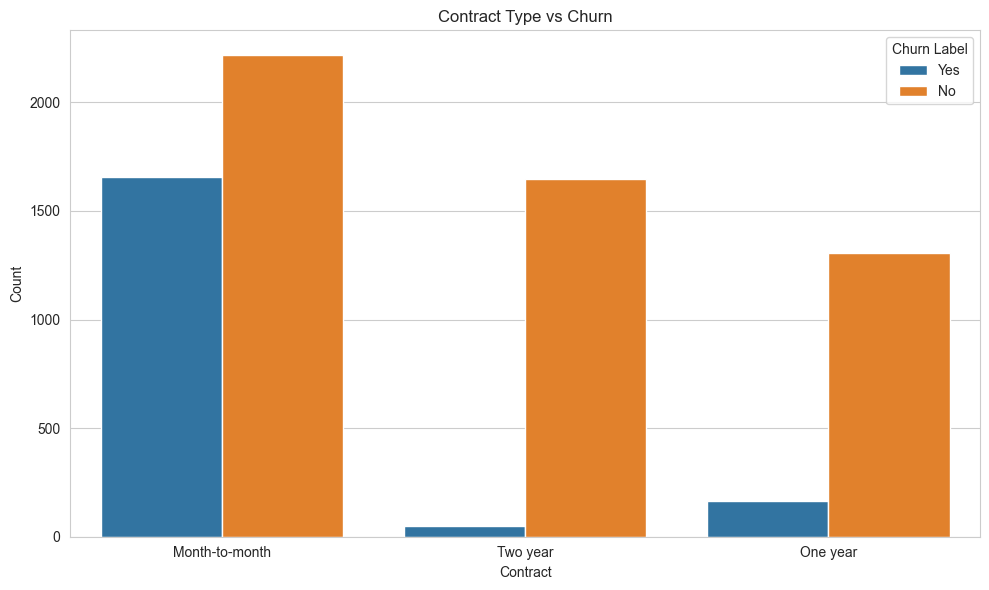

Churn Rate per Contract Type:
Contract
Month-to-month    42.71%
One year          11.27%
Two year           2.83%
Name: Yes, dtype: object


In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Contract Type vs Churn")
plt.xlabel("Contract")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "04_contract_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

rates = df.groupby('Contract')['Churn Label'].value_counts(normalize=True).unstack()
print("Churn Rate per Contract Type:")
print((rates['Yes'] * 100).round(2).astype(str) + '%')

### 6.5 Internet Service vs Churn Rate

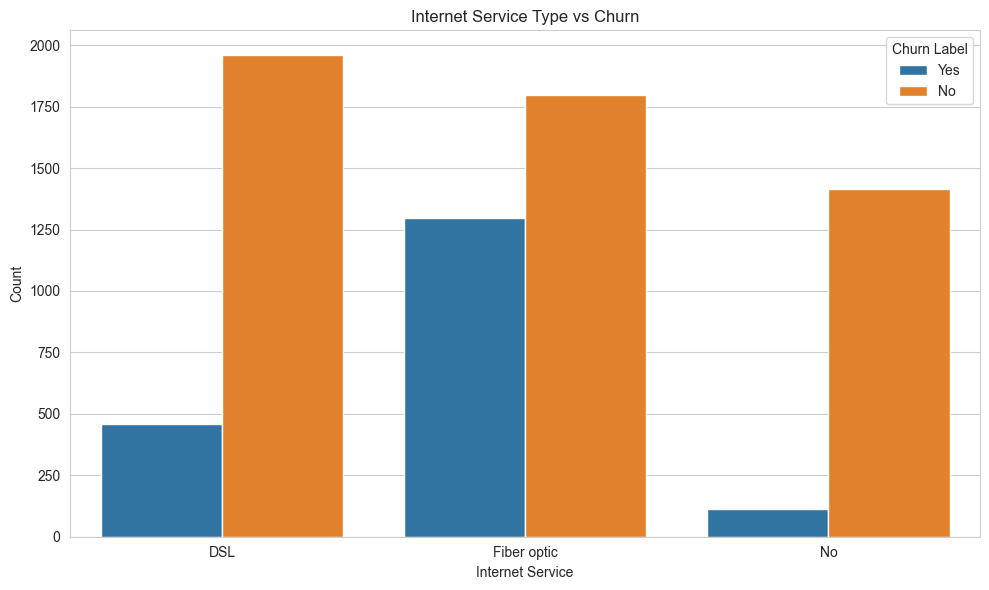

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Internet Service Type vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "05_internet_service_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.6 Numeric Feature Correlation Heatmap

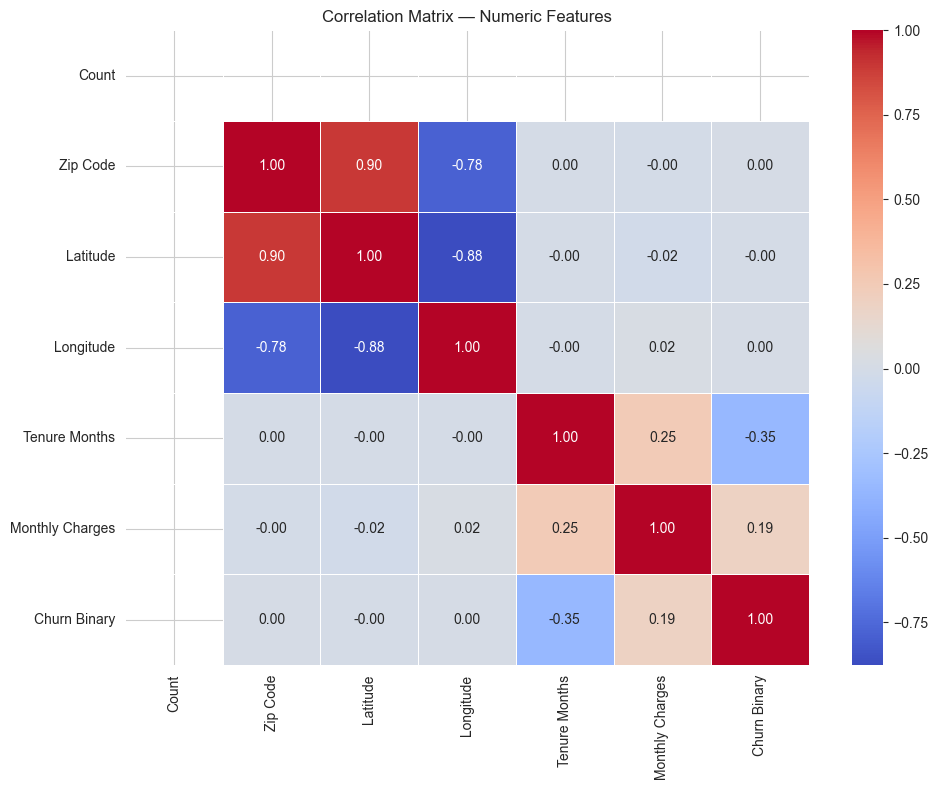

Top 3 numeric features correlated with churn:
Tenure Months      0.352229
Monthly Charges    0.193356
Longitude          0.004594
Name: Churn Binary, dtype: float64


In [16]:
df_num = df.select_dtypes(include='number').copy()
df_num["Churn Binary"] = (df["Churn Label"] == "Yes").astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

corrs = df_num.corr()["Churn Binary"].drop("Churn Binary").abs().sort_values(ascending=False)
print("Top 3 numeric features correlated with churn:")
print(corrs.head(3))

## 7. Preprocessing
In this section we fix data types, encode the target, and remove columns that cannot be used as model features.

### 7.1 Fix 'Total Charges' Data Type
Total Charges is stored as object (string). Rows with whitespace or empty strings must be handled before conversion.

In [ ]:
print(f"'Total Charges' dtype before: {df['Total Charges'].dtype}")
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
n_new_nulls = df['Total Charges'].isnull().sum()
print(f"New nulls created during conversion: {n_new_nulls}")
if n_new_nulls > 0:
    print("  → Preserving missing Total Charges values for training-only pipeline imputation.")
print(f"'Total Charges' dtype after:  {df['Total Charges'].dtype}")
print("✅ Total Charges converted without full-dataset imputation.")


### 7.2 Encode Target Column
Convert 'Churn Label' from Yes/No to binary 1/0. The original column is replaced. 1 = Churned, 0 = Not Churned.

In [18]:
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
print("Target encoding complete:")
print(df['Churn Label'].value_counts())
print(f"\nChurn Rate: {df['Churn Label'].mean()*100:.1f}%")

Target encoding complete:
Churn Label
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.5%


### 7.3 Drop Non-Predictive Columns
CustomerID, geographic coordinates, and Count are not useful features for prediction. We drop them now.

In [19]:
existing_drop = [c for c in DROP_COLUMNS if c in df.columns]
df = df.drop(columns=existing_drop)
print(f"Dropped {len(existing_drop)} columns: {existing_drop}")
print(f"Final shape: {df.shape}")
print(f"Remaining columns ({len(df.columns)}):")
for c in df.columns:
    print(f"  - {c}: {df[c].dtype}")

Dropped 9 columns: ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
Final shape: (7043, 20)
Remaining columns (20):
  - Gender: object
  - Senior Citizen: object
  - Partner: object
  - Dependents: object
  - Tenure Months: int64
  - Phone Service: object
  - Multiple Lines: object
  - Internet Service: object
  - Online Security: object
  - Online Backup: object
  - Device Protection: object
  - Tech Support: object
  - Streaming TV: object
  - Streaming Movies: object
  - Contract: object
  - Paperless Billing: object
  - Payment Method: object
  - Monthly Charges: float64
  - Total Charges: float64
  - Churn Label: int64


### 7.4 Export Data Summary

In [20]:
data_summary = pd.DataFrame({
    'Column': df.columns,
    'Dtype': [str(df[c].dtype) for c in df.columns],
    'Non_Null_Count': [df[c].notna().sum() for c in df.columns],
    'Null_Count': [df[c].isnull().sum() for c in df.columns],
    'Null_Pct': [(df[c].isnull().sum() / len(df) * 100).round(2) for c in df.columns],
    'Unique_Values': [df[c].nunique() for c in df.columns],
    'Sample_Values': [str(df[c].dropna().unique()[:3].tolist()) for c in df.columns]
})

data_summary.to_csv(SUMMARIES_PATH / "data_summary.csv", index=False, encoding='utf-8')
print(f"📁 Saved: {SUMMARIES_PATH / 'data_summary.csv'}")
display(data_summary)

📁 Saved: data\summaries\data_summary.csv


,Column,Dtype,Non_Null_Count,Null_Count,Null_Pct,Unique_Values,Sample_Values
0,Gender,object,7043,0,0.0,2,"['Male', 'Female']"
1,Senior Citizen,object,7043,0,0.0,2,"['No', 'Yes']"
2,Partner,object,7043,0,0.0,2,"['No', 'Yes']"
3,Dependents,object,7043,0,0.0,2,"['No', 'Yes']"
4,Tenure Months,int64,7043,0,0.0,73,"[2, 8, 28]"
5,Phone Service,object,7043,0,0.0,2,"['Yes', 'No']"
6,Multiple Lines,object,7043,0,0.0,3,"['No', 'Yes', 'No phone service']"
7,Internet Service,object,7043,0,0.0,3,"['DSL', 'Fiber optic', 'No']"
8,Online Security,object,7043,0,0.0,3,"['Yes', 'No', 'No internet service']"
9,Online Backup,object,7043,0,0.0,3,"['Yes', 'No', 'No internet service']"


### ✅ GATE 5 — Pre-Export Validation
_All checks must PASS before the cleaned dataset is saved._

In [ ]:
# CHECK 1
for col in LEAKAGE_COLUMNS:
    assert col not in df.columns, f"❌ LEAKAGE FOUND: {col}"
print("✅ GATE 5.1 PASS: No leakage columns.")

# CHECK 2
assert set(df[TARGET_COLUMN].dropna().unique()).issubset({0, 1}), "❌ Target column is not binary!"
print("✅ GATE 5.2 PASS: Target is binary 0/1.")

# CHECK 3
assert pd.api.types.is_numeric_dtype(df['Total Charges']), "❌ Total Charges is still non-numeric!"
print("✅ GATE 5.3 PASS: Total Charges is numeric.")

# CHECK 4
null_counts = df.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != 'Total Charges')]
assert unexpected_nulls.empty, f"❌ Unexpected null values found: {unexpected_nulls.to_dict()}"
print(f"✅ GATE 5.4 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain for training-only pipeline imputation.")

# CHECK 5
print(f"✅ GATE 5.5 INFO: Final row count = {len(df)}")

print("\n🟢 GATE 5 COMPLETE — Safe to export cleaned dataset.")


## 8. Export Cleaned Dataset

In [22]:
backup_if_overwriting(CLEANED_DATA_PATH, PROJECT_ROOT, "cleaned dataset")
df.to_csv(CLEANED_DATA_PATH, index=False, encoding='utf-8')
print(f"📁 Exported: {CLEANED_DATA_PATH}")
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Encoding: UTF-8")
print(f"   Target distribution:\n{df[TARGET_COLUMN].value_counts()}")
record_regeneration_step(
    PROJECT_ROOT,
    "01_preprocessing",
    "notebooks/01_moaz_eda_preprocessing.ipynb",
    [CLEANED_DATA_PATH],
)


📁 Exported: data\cleaned\cleaned_telco.csv
   Rows: 7043
   Columns: 20
   Encoding: UTF-8
   Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64


### ✅ GATE 6 — Export Validation
_Reads the file back from disk and confirms it was saved correctly._

In [ ]:
df_check = pd.read_csv(CLEANED_DATA_PATH)
errors = []

if len(df_check) == 0:
    errors.append("❌ GATE 6.1 FAIL: Exported file is empty.")
else:
    print(f"✅ GATE 6.1 PASS: File has {len(df_check)} rows.")

if TARGET_COLUMN not in df_check.columns:
    errors.append(f"❌ GATE 6.2 FAIL: Target column missing from export.")
else:
    print(f"✅ GATE 6.2 PASS: Target column '{TARGET_COLUMN}' present.")

for col in LEAKAGE_COLUMNS:
    if col in df_check.columns:
        errors.append(f"❌ GATE 6.3 FAIL: Leakage column '{col}' found in export!")
if not any("GATE 6.3" in e for e in errors):
    print("✅ GATE 6.3 PASS: No leakage columns in exported file.")

null_counts = df_check.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != 'Total Charges')]
if not unexpected_nulls.empty:
    errors.append(f"❌ GATE 6.4 FAIL: Unexpected nulls found: {unexpected_nulls.to_dict()}")
else:
    print(f"✅ GATE 6.4 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain.")

if errors:
    for e in errors:
        print(e)
    raise ValueError("❌ GATE 6 FAILED. Do NOT pass this file to Mohy.")
else:
    print(f"\n🟢 GATE 6 COMPLETE — cleaned_telco.csv is valid and ready.")
    print(f"📬 HANDOFF READY → 02_mohy_feature_engineering.ipynb")


## 9. Summary & Handoff

### What was accomplished in this notebook:
- ✅ Loaded Telco Churn dataset (7,043 rows × 33 columns)
- ✅ Removed 4 leakage columns: Churn Score, Churn Value, Churn Reason, CLTV
- ✅ Fixed `Total Charges` from object → float64
- ✅ Encoded `Churn Label` → binary (1 = Churned, 0 = Not Churned)
- ✅ Removed 9 non-predictive ID/geographic columns
- ✅ Confirmed no unexpected missing values
- ✅ Confirmed no duplicate rows
- ✅ Generated 6 EDA visualizations
- ✅ Exported: `data/cleaned/cleaned_telco.csv`
- ✅ Exported: `data/summaries/data_summary.csv`
- ✅ Exported: `data/summaries/missing_values.csv`

### Key EDA Findings:
- **Churn Rate:** ~26.5% (class imbalance exists — Mohy will address)
- **Contract Type:** Month-to-month customers churn significantly more
- **Tenure:** Short-tenure customers have higher churn risk
- **Monthly Charges:** Churned customers have higher average monthly charges
- **Internet Service:** Fiber optic users show higher churn rates

### Handoff to Mohamed Mohy:
**Read file:** `data/cleaned/cleaned_telco.csv`
**Notebook:** `02_mohy_feature_engineering.ipynb`

Mohy will perform:
- Feature engineering
- Categorical encoding
- Feature selection
- Scaling pipeline preparation

> ⚠️ Do NOT modify `cleaned_telco.csv` after export.
> If re-running is needed, re-run this FULL notebook from Cell 01.